<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/03_2_Hernandez_Alvaro_TranferenciaAprendizaje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio de transferencia de aprendizaje**

* Asignatura: Redes Neuronales Profundas
* Profesor: Dr. José David Díaz Román
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 1 de marzo de 2026




# **Indicaciones**

El archivo compartido representa un ejemplo de aplicación de transferencia de aprendizaje utilizando datos de imágenes histopatológicas. En el ejercicio que realizamos en clase trabajamos con imágenes de colon; sin embargo, para este problema deberán trabajar con imágenes histopatológicas de pulmón.<br>
En la siguiente liga podrán descargar la base de datos (que incluye tanto imágenes de pulmón como de colon): https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images <br>

La tarea es que implementen al menos tres redes neuronales de su preferencia aplicando transferencia de aprendizaje. Para ello deberán congelar las capas convolucionales del modelo base y entrenar únicamente las capas densas que se añadan en la etapa de clasificación.
Tomen en cuenta que la base de datos de imágenes de pulmón contiene tres clases:
* Tejido sano
* Adenocarcinoma
* Carcinoma de células escamosas

En las pruebas que realicen, se espera que obtengan al menos 96% de exactitud en la clasificación. En cada experimento deben presentar la matriz de confusión correspondiente a las predicciones en el conjunto de validación. <br>
El conjunto de validación debe representar el 15% de los datos.


In [1]:
# 1. Copiar el archivo desde tu Drive al almacenamiento local de Colab (/content/)
!cp "/content/drive/MyDrive/ClassFiles/archive.zip" "/content/"

# 2. Descomprimir el archivo de forma silenciosa (-q) en una carpeta llamada "datos_locales"
!unzip -q "/content/archive.zip" -d "/content/datos_locales/"

# 3. Borrar el .zip temporal local para liberar espacio en la memoria de Colab
!rm "/content/archive.zip"

In [2]:
# Librerías y funciones a utilizar

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from random import seed, randint

In [3]:
# 🔧 Configurar GPU para asignar memoria de forma dinámica
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Memoria de GPU configurada para crecimiento dinámico.")
    except RuntimeError as e:
        print("❌ Error al configurar memoria de GPU:", e)

In [4]:
directory = "/content/datos_locales/lung_colon_image_set/lung_image_sets"

generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.15,
    fill_mode='nearest'
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    validation_split=0.15
)

training_generator = generator.flow_from_directory(
    directory,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    subset='training',
    seed=30,
)

val_generator = val_datagen.flow_from_directory(
    directory,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=False, # <-- Crucial en False
    subset='validation',
    seed=30,
)

Found 12750 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.


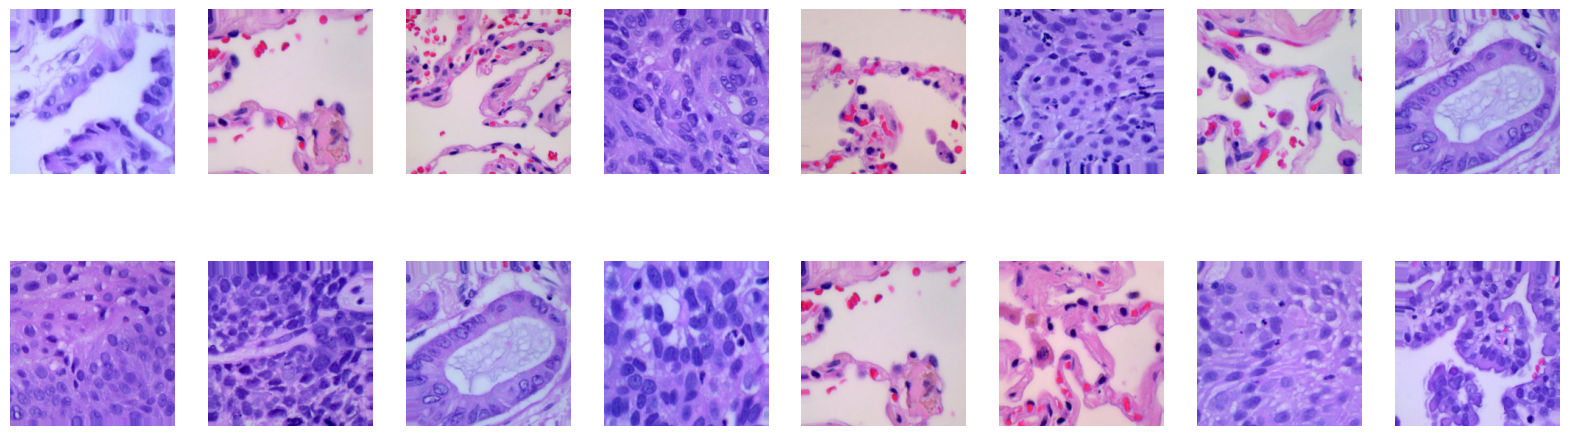

In [5]:
x,y=next(training_generator)

# Visualización de imágenes

plt.figure(1, figsize=(20,6))
plt.tight_layout()
for i in range(8):
    j = randint(0, x.shape[0]-1)
    plt.subplot(2, 8, i+1)
    plt.imshow(x[j,:,:,:].astype(np.uint8), cmap='gray')
    plt.axis("off")
    j = randint(0, x.shape[0]-1)
    plt.subplot(2, 8, i+9)
    plt.imshow(x[j,:,:,:].astype(np.uint8), cmap='gray')
    plt.axis("off")
plt.show()

## Segundo modelo. **ResNet50**

In [6]:
base_model_2 = ResNet50(
    weights='imagenet',
    input_shape=(224, 224, 3),
    include_top=False,
    pooling="avg"
)

base_model_2.trainable = False

input_2 = tf.keras.layers.Input(shape=(224, 224, 3))

x2 = preprocess_resnet(input_2)
x2 = base_model_2(x2)
x2 = keras.layers.Dropout(0.2)(x2)
x2 = keras.layers.Dense(256, activation='relu')(x2)
x2 = keras.layers.BatchNormalization()(x2)
x2 = keras.layers.Dense(64, activation='relu')(x2)
x2 = keras.layers.BatchNormalization()(x2)
output_2 = keras.layers.Dense(3, activation='softmax')(x2)

model_2 = Model(inputs=input_2, outputs=output_2)

model_2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

print(model_2.summary())

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2048)      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ resnet50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     16,448 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        195 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,130,179 (92.05 MB)

 Trainable params: 541,827 (2.07 MB)

 Non-trainable params: 23,588,352 (89.98 MB)

None


In [7]:
class BarreraExactitud(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') >= 0.96:
            print(f"\n✅ ¡Objetivo alcanzado! Exactitud del {logs.get('val_accuracy'):.4f}.")
            print("Deteniendo el entrenamiento...")
            self.model.stop_training = True

barrera_96 = BarreraExactitud()

history_2 = model_2.fit(
    x=training_generator,
    batch_size=32,
    epochs=5,
    verbose=1,
    validation_data=val_generator,
    shuffle=True,
    callbacks=[barrera_96]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8310 - loss: 0.4064
✅ ¡Objetivo alcanzado! Exactitud del 0.9618.
Deteniendo el entrenamiento...
399/399 ━━━━━━━━━━━━━━━━━━━━ 1922s 5s/step - accuracy: 0.8312 - loss: 0.4061 - val_accuracy: 0.9618 - val_loss: 0.0965


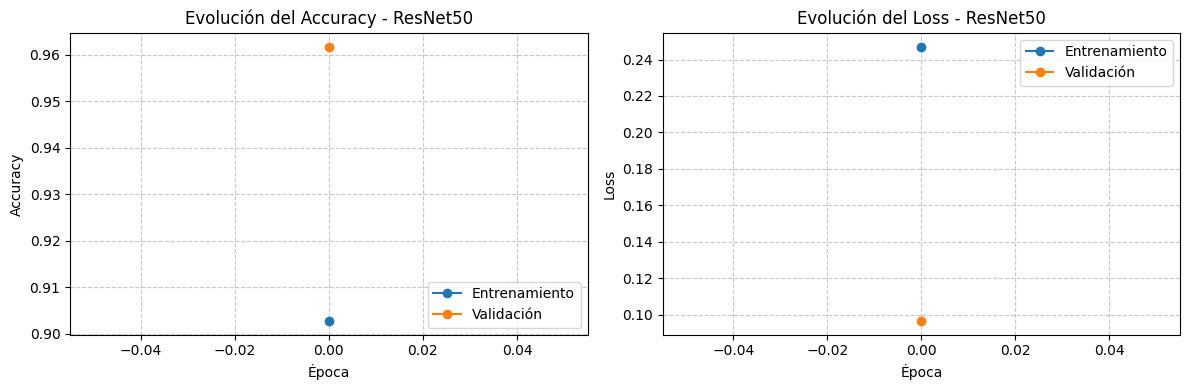

In [8]:
plt.figure(figsize=(12, 4))

# Gráfica de Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'], label='Entrenamiento', marker='o')
plt.plot(history_2.history['val_accuracy'], label='Validación', marker='o')
plt.title('Evolución del Accuracy - ResNet50')
plt.ylabel('Accuracy')
plt.xlabel('Época')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfica de Loss
plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'], label='Entrenamiento', marker='o')
plt.plot(history_2.history['val_loss'], label='Validación', marker='o')
plt.title('Evolución del Loss - ResNet50')
plt.ylabel('Loss')
plt.xlabel('Época')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Evaluación del segundo modelo**

71/71 ━━━━━━━━━━━━━━━━━━━━ 273s 4s/step


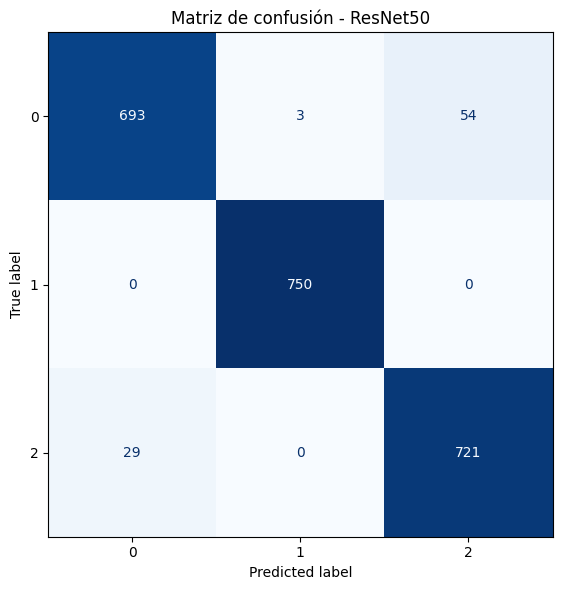


Reporte de clasificación ResNet50:
              precision    recall  f1-score   support

           0     0.9598    0.9240    0.9416       750
           1     0.9960    1.0000    0.9980       750
           2     0.9303    0.9613    0.9456       750

    accuracy                         0.9618      2250
   macro avg     0.9621    0.9618    0.9617      2250
weighted avg     0.9621    0.9618    0.9617      2250



In [9]:
# Predicciones
val_generator.reset()

y_pred_probs_2 = model_2.predict(val_generator, verbose=1)
y_pred_2 = np.argmax(y_pred_probs_2, axis=1)
y_true = val_generator.classes

# Matriz de confusión
cm_2 = confusion_matrix(y_true, y_pred_2, labels=np.arange(3))
disp_2 = ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=np.arange(3))
fig, ax = plt.subplots(figsize=(6, 6))
disp_2.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Matriz de confusión - ResNet50")
plt.tight_layout()
plt.show()

# Reporte de clasificación
print("\nReporte de clasificación ResNet50:")
print(classification_report(y_true, y_pred_2, digits=4))